# Laufzeitvergleich der Sortieralgorithmen

Liest die Benchmark-Ausgaben (`quicksort.txt`, `mergesort.txt`, ...) die von `main.cpp` erzeugt werden und plottet die durchschnittliche Laufzeit gegen die Eingabegröße `n`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [ ]:
# Mapping: file -> (display name, marker, color)
ALGORITHMS = {
    "quicksort.txt":    ("QuickSort",    "+",  "black"),
    "mergesort.txt":    ("MergeSort",    "x",  "#2ca02c"),   # green
    "heapsort.txt":     ("HeapSort",     "*",  "#1f77b4"),   # blue
    "shellsort_2n.txt": ("ShellSort",    "s",  "#ff7f0e"),   # orange
    "counting.txt":     ("CountingSort", "o",  "#9467bd"),   # purple
    "radix.txt":        ("RadixSort",    "^",  "#17becf"),   # cyan
}

DATA_DIR = Path("./data")    

# The C++ code writes std::chrono::steady_clock tick counts, which on most
# platforms are nanoseconds. Convert to seconds to match the original plot.
TIME_SCALE = 1e-9  # set to 1.0 if your output is already in seconds

In [3]:
def load(fname: str) -> pd.DataFrame:
    path = DATA_DIR / fname
    df = pd.read_csv(path, sep=r"\s+", names=["n", "t"])
    df["t"] = df["t"] * TIME_SCALE
    return df

# Quick sanity check — only loads files that exist
datasets = {}
for fname, (label, marker, color) in ALGORITHMS.items():
    p = DATA_DIR / fname
    if p.exists():
        datasets[fname] = load(fname)
        print(f"{fname:20s} -> {len(datasets[fname])} rows")
    else:
        print(f"{fname:20s} -> NOT FOUND (run main.cpp first)")

quicksort.txt        -> 100 rows
mergesort.txt        -> 100 rows
heapsort.txt         -> 100 rows
shellsort_2n.txt     -> 100 rows
counting.txt         -> 100 rows
radix.txt            -> 100 rows


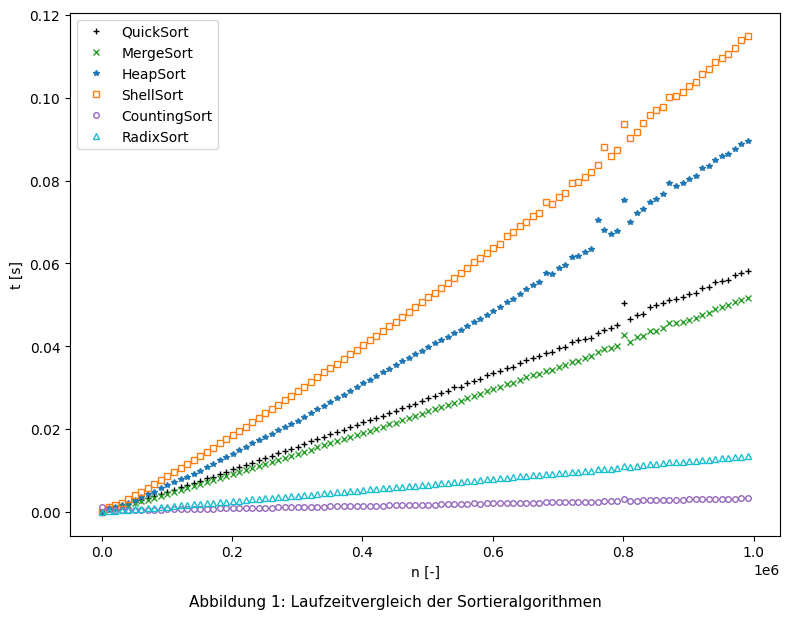

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))

for fname, df in datasets.items():
    label, marker, color = ALGORITHMS[fname]
    ax.plot(df["n"], df["t"],
            linestyle="none",
            marker=marker,
            markersize=4,
            markerfacecolor="none" if marker in ("s", "o", "^") else color,
            markeredgecolor=color,
            label=label)

ax.set_xlabel("n [-]")
ax.set_ylabel("t [s]")
ax.legend(loc="upper left", frameon=True)
ax.grid(False)
ax.spines["top"].set_visible(True)
ax.spines["right"].set_visible(True)

# Caption underneath, matching the "Abbildung 1" style
fig.text(0.5, -0.02,
         "Abbildung 1: Laufzeitvergleich der Sortieralgorithmen",
         ha="center", fontsize=11)

plt.tight_layout()
plt.savefig("laufzeitvergleich.png", dpi=150, bbox_inches="tight")
plt.show()

## Optional: log-log Darstellung

Auf logarithmischen Achsen lassen sich die theoretischen Komplexitätsklassen ($O(n)$, $O(n \log n)$, $O(n^2)$) besser unterscheiden — die Steigung der Geraden entspricht dem Exponenten.

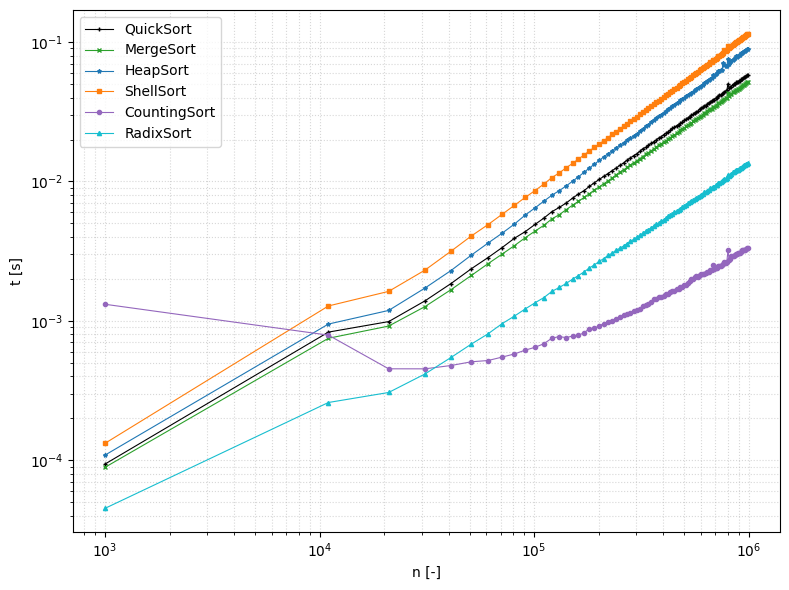

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))

for fname, df in datasets.items():
    label, marker, color = ALGORITHMS[fname]
    ax.plot(df["n"], df["t"],
            linestyle="-", linewidth=0.8,
            marker=marker, markersize=3,
            color=color, label=label)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("n [-]")
ax.set_ylabel("t [s]")
ax.legend(loc="upper left")
ax.grid(True, which="both", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()